# Nuclear Segmentation — two-stage walkthrough

**Stage 1:** run the Cellpose nucleus model on your 2-channel images (nucleus + membrane) and save `*_seg.npy` files.
**Stage 2:** rebuild nuclear masks from the flow (divergence + h-maxima seeding), same logic as the membrane pipeline but with the veto OFF.

Edit the paths and the Cellpose settings (`MODEL_PATH`, `CELLPOSE_CHANNELS`, `NUCLEUS_DIAMETER`, `IMAGE_FILENAME`) inside `flow_nuclear_seg.py` first, or override them in the config cell below.


## 0. Imports & paths


In [1]:
import importlib, flow_nuclear_seg
importlib.reload(flow_nuclear_seg)

<module 'flow_nuclear_seg' from '/Users/amir/Desktop/14.July/flow_nuclear_seg.py'>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tifffile as tiff

import flow_nuclear_seg as fn   # the packaged module (same folder)

# --- paths ---
IMAGE_DIR = Path('/Users/amir/data/positivity_map/version_2/segmetation/test/A_3d')          # per-FOV subfolders with the 2-ch image
# stage 1 writes *_nuclear_seg.npy next to each image, inside its own FOV folder.
# stage 2 writes masks into the same FOV folders. No separate output folder needed.

# You can also override the module's Cellpose settings here:
# fn.MODEL_PATH = '/path/to/model'
# fn.CELLPOSE_CHANNELS = [1, 2]
# fn.NUCLEUS_DIAMETER = 30
# fn.IMAGE_FILENAME = 'image.tiff'


## 1. STAGE 1 — run the Cellpose nucleus model
Writes one `*_seg.npy` per FOV into `SEG_DIR`. Run once; it can take a while for many FOVs.


In [3]:
model = fn.load_model()                       # custom model if MODEL_PATH set, else built-in 'nuclei'
fn.run_cellpose_folder(str(IMAGE_DIR), str(IMAGE_DIR), model=model)


/Users/amir/micromamba/envs/cellpose/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Loading custom nucleus model: /Users/amir/.cellpose/models/nucleitorch_0
Stage 1: 1 FOV folders found

  [1/1] A_3d_C01_R01: 184 nuclei -> /Users/amir/data/positivity_map/version_2/segmetation/test/A_3d/A_3d_C01_R01/A_3d_C01_R01_nuclear.npy

Stage 1 done. Feed seg_dir into stage 2.


## 2. Quick look — image vs flow (one FOV)
Sanity-check that the flow looks sensible before rebuilding masks. Pick any `*_seg.npy` from stage 1.


1 seg files


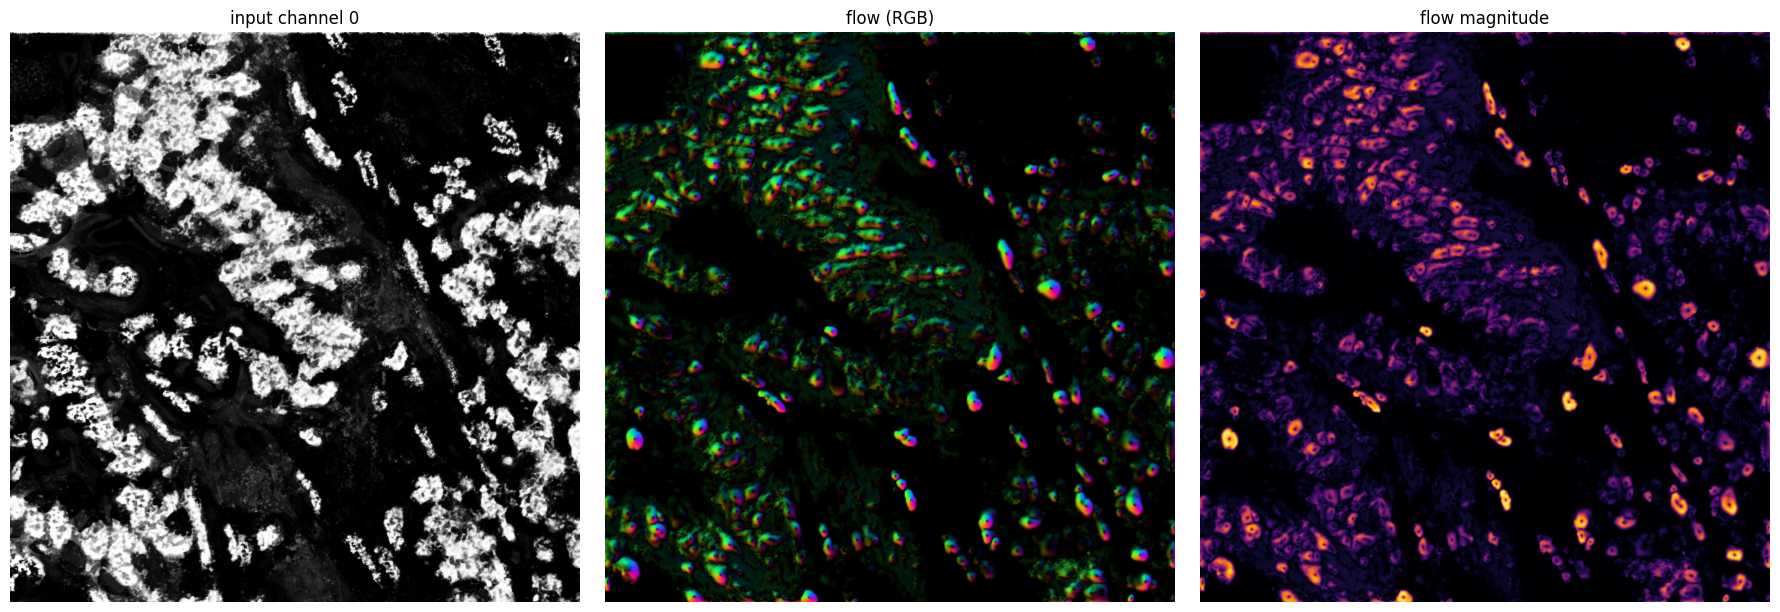

In [10]:
seg_files = sorted(IMAGE_DIR.rglob('*_nuclear_seg.npy'))
print(len(seg_files), 'seg files')
seg = fn.load_seg(str(seg_files[0]))           # look at the first one; change index to inspect others

img = np.asarray(seg['img']).astype(np.float32)   # (2, H, W)
rgb_flow = np.asarray(seg['flows'][0]).squeeze()   # Cellpose's RGB flow visualization
dY, dX, cellprob = fn.raw_flows(seg)
mag = np.sqrt(dY**2 + dX**2)                        # flow strength

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img[0], cmap='gray'); ax[0].set_title('input channel 0'); ax[0].axis('off')
ax[1].imshow(rgb_flow); ax[1].set_title('flow (RGB)'); ax[1].axis('off')
ax[2].imshow(mag, cmap='inferno'); ax[2].set_title('flow magnitude'); ax[2].axis('off')
plt.tight_layout(); plt.show()


## 3. STAGE 2 (single FOV) — rebuild nuclear masks & tune
Runs the flow reconstruction on the FOV loaded above. `use_veto` is OFF by default for nuclei. Tune `sink_h` (merge<->split) if touching nuclei are under- or over-split.


nuclei found : 396
nucleus is plane 0  <-- confirm this is really your nucleus channel


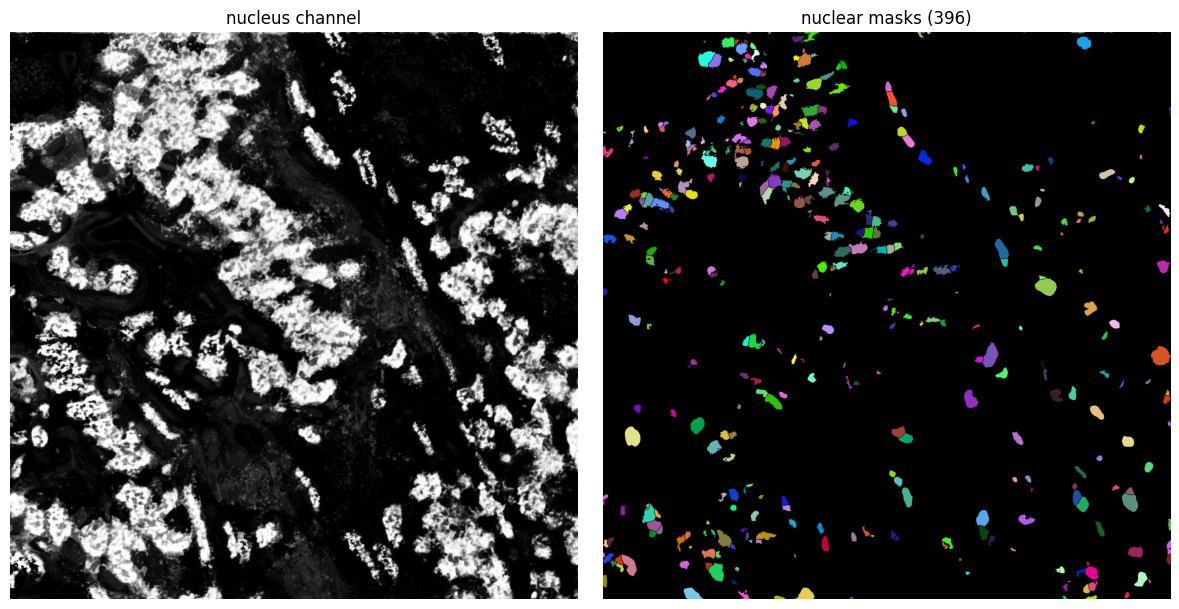

In [4]:
params = fn.Params(sink_h=0.12)               # veto is already OFF by default for nuclei
labels, ctx = fn.run_pipeline(seg, params)
print('nuclei found :', int(labels.max()))
print('nucleus is plane', ctx['nuc_plane'], ' <-- confirm this is really your nucleus channel')

from skimage.segmentation import find_boundaries
rng = np.random.default_rng(0)
lut = rng.random((int(labels.max())+1, 3)); lut[0] = 0
lab_rgb = lut[labels]; lab_rgb[find_boundaries(labels, mode='inner')] = 0
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img[0], cmap='gray'); ax[0].set_title('nucleus channel'); ax[0].axis('off')
ax[1].imshow(lab_rgb); ax[1].set_title(f'nuclear masks ({int(labels.max())})'); ax[1].axis('off')
plt.tight_layout(); plt.show()


## 4. STAGE 2 (batch) — rebuild masks for every FOV
Reads every `*_seg.npy` in `SEG_DIR`, writes `.labels.npy`, `.labels.tif`, `.cells.csv` into `OUT_DIR`.


In [ ]:
params = fn.Params(sink_h=0.12)               # use the value you settled on above
seg_files = sorted(IMAGE_DIR.rglob('*_nuclear_seg.npy'))
print(f'{len(seg_files)} FOVs to reconstruct\n')

for sp in seg_files:
    seg = fn.load_seg(str(sp))
    labels, ctx = fn.run_pipeline(seg, params)
    name = sp.stem.replace('_nuclear_seg', '')
    tiff.imwrite(str(out / f'{name}.labels.tif'), labels.astype(np.uint16))
    print(f'{name}: {int(labels.max())} nuclei')

print('\ndone.')
